In [2]:
import pandas as pd

df = pd.read_csv("invoices.csv")
df.head()

,invoice_id,customer,invoice_date,amount,payment_terms_days,due_date,payment_date,paid_late
0,INV10289,Cosmo Retail,2024-01-01,4166.87,30,2024-01-31,2024-02-18,Yes
1,INV10185,Beta Logistics,2024-01-02,2381.40,30,2024-02-01,2024-02-06,Yes
2,INV10572,Iris Design,2024-01-04,2378.90,60,2024-03-04,2024-01-21,No
3,INV10328,Jade Marine,2024-01-04,15276.17,45,2024-02-18,2024-02-17,No
4,INV10275,Delta Foods,2024-01-06,6758.23,30,2024-02-05,2024-01-26,No


In [3]:
df.shape

(600, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   invoice_id          600 non-null    str    
 1   customer            600 non-null    str    
 2   invoice_date        600 non-null    str    
 3   amount              600 non-null    float64
 4   payment_terms_days  600 non-null    int64  
 5   due_date            600 non-null    str    
 6   payment_date        600 non-null    str    
 7   paid_late           600 non-null    str    
dtypes: float64(1), int64(1), str(6)
memory usage: 68.5 KB


In [5]:
df["paid_late"].value_counts()

paid_late
No     404
Yes    196
Name: count, dtype: int64

In [6]:
df.groupby("customer")["paid_late"].value_counts()

customer        paid_late
Alpha Trading   No           43
                Yes          11
Beta Logistics  Yes          25
                No           24
Cosmo Retail    No           55
                Yes          11
Delta Foods     Yes          42
                No           18
Evergreen Tech  No           53
                Yes           5
Falcon Media    No           40
                Yes          25
Grand Hotels    No           38
                Yes          10
Horizon Pharma  No           61
                Yes          10
Iris Design     Yes          32
                No           25
Jade Marine     No           47
                Yes          25
Name: count, dtype: int64

In [7]:
df["paid_late"].value_counts()

paid_late
No     404
Yes    196
Name: count, dtype: int64

In [8]:
df.groupby("customer")["paid_late"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)

customer
Delta Foods       70.000000
Iris Design       56.140351
Beta Logistics    51.020408
Falcon Media      38.461538
Jade Marine       34.722222
Grand Hotels      20.833333
Alpha Trading     20.370370
Cosmo Retail      16.666667
Horizon Pharma    14.084507
Evergreen Tech     8.620690
Name: paid_late, dtype: float64

In [9]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"])
df["due_date"] = pd.to_datetime(df["due_date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   invoice_id          600 non-null    str           
 1   customer            600 non-null    str           
 2   invoice_date        600 non-null    datetime64[us]
 3   amount              600 non-null    float64       
 4   payment_terms_days  600 non-null    int64         
 5   due_date            600 non-null    datetime64[us]
 6   payment_date        600 non-null    str           
 7   paid_late           600 non-null    str           
dtypes: datetime64[us](2), float64(1), int64(1), str(4)
memory usage: 56.8 KB


In [10]:
df["invoice_month"] = df["invoice_date"].dt.month
df["is_december"] = (df["invoice_month"] == 12).astype(int)
df[["invoice_date", "invoice_month", "is_december"]].head()

,invoice_date,invoice_month,is_december
0,2024-01-01,1,0
1,2024-01-02,1,0
2,2024-01-04,1,0
3,2024-01-04,1,0
4,2024-01-06,1,0


In [11]:
df["late"] = (df["paid_late"] == "Yes").astype(int)
df[["paid_late", "late"]].head()

,paid_late,late
0,Yes,1
1,Yes,1
2,No,0
3,No,0
4,No,0


In [12]:
df_model = pd.get_dummies(df[["customer", "amount", "payment_terms_days", "invoice_month", "is_december", "late"]], columns=["customer"], dtype=int)
df_model.head()

,amount,payment_terms_days,invoice_month,is_december,late,customer_Alpha Trading,customer_Beta Logistics,customer_Cosmo Retail,customer_Delta Foods,customer_Evergreen Tech,customer_Falcon Media,customer_Grand Hotels,customer_Horizon Pharma,customer_Iris Design,customer_Jade Marine
0,4166.87,30,1,0,1,0,0,1,0,0,0,0,0,0,0
1,2381.40,30,1,0,1,0,1,0,0,0,0,0,0,0,0
2,2378.90,60,1,0,0,0,0,0,0,0,0,0,0,1,0
3,15276.17,45,1,0,0,0,0,0,0,0,0,0,0,0,1
4,6758.23,30,1,0,0,0,0,0,1,0,0,0,0,0,0


In [13]:
df_model.shape


(600, 15)

In [14]:
X = df_model.drop(columns=["late"])
y = df_model["late"]
print(X.shape, y.shape)

(600, 14) (600,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(480, 14) (120, 14)


In [18]:
!pip install scikit-learn

In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [20]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)
accuracy_score(y_test, predictions)

0.675

In [21]:
model = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy_score(y_test, predictions)

0.6833333333333333

In [22]:
proba = model.predict_proba(X_test)[:, 1]

results = df.loc[X_test.index, ["invoice_id", "customer", "amount", "paid_late"]].copy()
results["risk_score"] = (proba * 100).round(0)
results.sort_values("risk_score", ascending=False).head(15)

,invoice_id,customer,amount,paid_late,risk_score
426,INV10546,Delta Foods,2540.52,No,63.0
441,INV10293,Delta Foods,4927.85,Yes,59.0
39,INV10497,Delta Foods,5112.73,Yes,58.0
209,INV10591,Iris Design,1039.37,No,57.0
11,INV10022,Delta Foods,2127.95,Yes,57.0
73,INV10243,Delta Foods,9140.55,Yes,56.0
2,INV10572,Iris Design,2378.90,No,55.0
30,INV10432,Iris Design,4408.66,No,55.0
329,INV10240,Delta Foods,5182.27,Yes,54.0
312,INV10186,Beta Logistics,1645.11,Yes,52.0


In [23]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importance.round(3)

amount                     0.235
customer_Delta Foods       0.175
invoice_month              0.146
customer_Iris Design       0.122
payment_terms_days         0.070
customer_Evergreen Tech    0.055
customer_Horizon Pharma    0.054
customer_Beta Logistics    0.036
customer_Cosmo Retail      0.035
customer_Grand Hotels      0.019
customer_Falcon Media      0.018
is_december                0.017
customer_Alpha Trading     0.009
customer_Jade Marine       0.008
dtype: float64

In [24]:
new_invoice = pd.DataFrame([{
    "amount": 15000,
    "payment_terms_days": 30,
    "invoice_month": 12,
    "is_december": 1,
    "customer": "Delta Foods"
}])

new_invoice = pd.get_dummies(new_invoice, columns=["customer"], dtype=int)
new_invoice = new_invoice.reindex(columns=X.columns, fill_value=0)

risk = model.predict_proba(new_invoice)[0, 1]
print(f"Risk of late payment: {risk*100:.0f}%")

Risk of late payment: 61%


In [25]:
import joblib
joblib.dump(model, "late_payment_model.pkl")
joblib.dump(list(X.columns), "model_columns.pkl")

['model_columns.pkl']

Accuracy: 0.683
Baseline (always not late): 0.667
ROC AUC: 0.733
Top-15 riskiest invoices that were actually late: 10 of 15


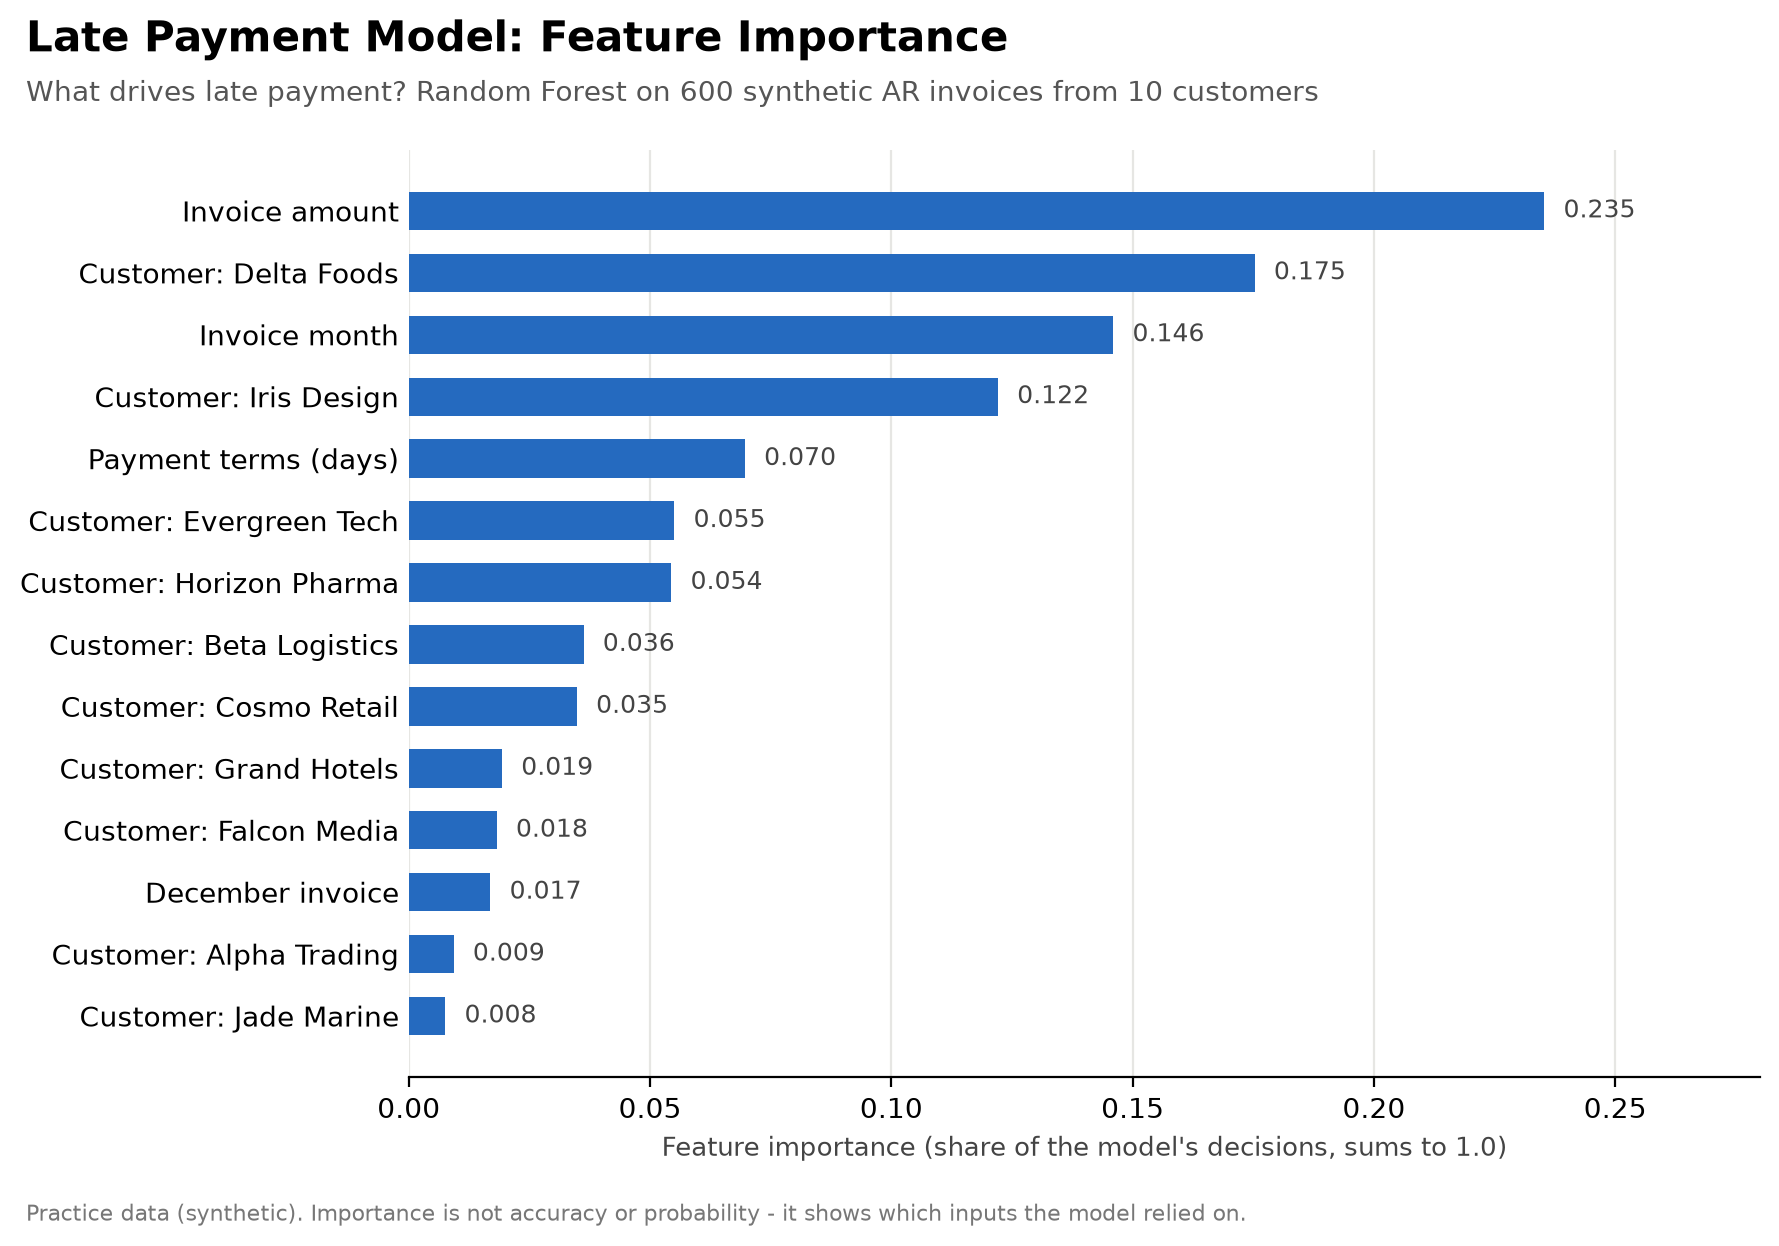

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
df = pd.read_csv("invoices.csv")
df["invoice_date"] = pd.to_datetime(df["invoice_date"])
df["invoice_month"] = df["invoice_date"].dt.month
df["is_december"] = (df["invoice_month"] == 12).astype(int)
df["late"] = (df["paid_late"] == "Yes").astype(int)
df_model = pd.get_dummies(df[["customer", "amount", "payment_terms_days", "invoice_month", "is_december", "late"]], columns=["customer"], dtype=int)
X = df_model.drop(columns=["late"])
y = df_model["late"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
print("Accuracy:", round(accuracy_score(y_test, model.predict(X_test)), 3))
print("Baseline (always not late):", round(1 - y_test.mean(), 3))
print("ROC AUC:", round(roc_auc_score(y_test, proba), 3))
top15 = pd.DataFrame({"actual_late": y_test.values, "risk": proba}).sort_values("risk", ascending=False).head(15)
print("Top-15 riskiest invoices that were actually late:", top15["actual_late"].sum(), "of 15")
importance = pd.Series(model.feature_importances_, index=X.columns)
imp = importance.sort_values()
labels = [i.replace("customer_", "Customer: ").replace("amount", "Invoice amount").replace("invoice_month", "Invoice month").replace("payment_terms_days", "Payment terms (days)").replace("is_december", "December invoice") for i in imp.index]
fig, ax = plt.subplots(figsize=(9, 6.2), dpi=200)
bars = ax.barh(labels, imp.values, color="#256abf", height=0.62)
for b, v in zip(bars, imp.values): ax.text(v + 0.004, b.get_y() + b.get_height()/2, f"{v:.3f}", va="center", fontsize=9, color="#444")
ax.set_xlim(0, 0.28)
for s in ["top", "right", "left"]: ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.xaxis.grid(True, color="#e6e6e3"); ax.set_axisbelow(True)
ax.set_xlabel("Feature importance (share of the model's decisions, sums to 1.0)", fontsize=9.5, color="#444")
fig.text(0.02, 0.955, "Late Payment Model: Feature Importance", fontsize=15, fontweight="bold")
fig.text(0.02, 0.915, "What drives late payment? Random Forest on 600 synthetic AR invoices from 10 customers", fontsize=10, color="#555")
fig.text(0.02, 0.012, "Practice data (synthetic). Importance is not accuracy or probability - it shows which inputs the model relied on.", fontsize=8, color="#777")
plt.tight_layout(rect=[0, 0.035, 1, 0.90])
fig.savefig("feature_importance.png", facecolor="white")
plt.show()